## Notebook with analysis pertaining to Figure 2
Also contains the code to export data for Supplemental Table 7

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [ ]:
# From annotations/add_annot_to_clusters.ipynb
pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")
pdb_clusters['chain_id_0'] = pdb_clusters['chain_id_0'].fillna('NA')
pdb_clusters['chain_id_1'] = pdb_clusters['chain_id_1'].fillna('NA')
# From annotations/create_cluster_summary.ipynb
cluster_summary = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_cluster_summary.tsv", sep="\t")

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_20650/2125341905.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv", sep="\t")


In [3]:
print(pdb_clusters[pdb_clusters['dimerrep'] == 1].shape[0])
print(pdb_clusters['intcluster'].nunique())

189830
77167


In [4]:
dimer_clust_size = pdb_clusters.groupby('dimercluster')['old_complex_id'].count().to_frame()
dimer_clust_size.columns = ["cluster_size"]
int_clust_size = pdb_clusters.groupby('intcluster')['old_complex_id'].count().to_frame()
int_clust_size.columns = ["cluster_size"]

singleton_ids = list(set(int_clust_size[int_clust_size["cluster_size"] == 1].index))

## Supplementary Table 7

In [6]:
cluster_summary_tocsv = cluster_summary.drop(["num_pfams","top_pfam","pct_top_pfam","num_caths","top_cath","pct_top_cath","top_go","pct_top_go","num_keywords","top_keyword","pct_top_keyword"], axis=1)
cluster_summary_tocsv.loc[:, "afmm_train_split"] = "Pre-training"
cluster_summary_tocsv.loc[cluster_summary_tocsv["first_date"] > 20210930, "afmm_train_split"] = "Post-training"
cluster_summary_tocsv.rename(columns={"intcluster":"cluster_id"})
cluster_summary_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/pdb_interface_cluster_annotations.csv", index=None)

## Panel b

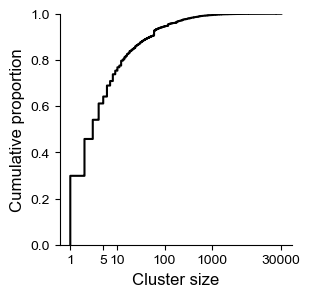

In [5]:
logs = [np.log10(x) for x in int_clust_size.cluster_size]

fig, ax = plt.subplots(figsize=(3,3))
ax.ecdf(logs, label='Interface clusters', color='black')
ax.set_xlabel('Cluster size', fontsize=global_fontsize, color='black')
ax.set_ylabel('Cumulative proportion', fontsize=global_fontsize, color='black')
ax.set_xticks([np.log10(1),np.log10(5),np.log10(10),np.log10(100),np.log10(1000),np.log10(30000)])
ax.set_xticklabels(['1','5','10','100','1000','30000'], fontsize=10)
ax.tick_params(axis='both', labelsize=10, labelcolor='black', color='black')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/pdb_cluster_size_distribution.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/pdb_cluster_size_distribution.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

In [6]:
int_clust_size[((int_clust_size["cluster_size"] >= 2) & (int_clust_size["cluster_size"] <= 100))].shape[0]

49920

## Panel d

See notebook "cath_interface_secondary_structure_analysis.ipynb"

## Panel e

In [ ]:
cluster_summary["iftype_pct_total"] = cluster_summary[["pct_ordord", "pct_disord", "pct_disdis"]].apply(lambda x: np.nansum(x), axis=1)
cluster_summary["iftype_pct_disorder"] = cluster_summary[["pct_disord", "pct_disdis"]].apply(lambda x: np.nansum(x), axis=1)
cluster_summary["pct_disorder"] = cluster_summary["iftype_pct_disorder"] / cluster_summary["iftype_pct_total"]
cluster_summary["pct_order"] = cluster_summary["pct_ordord"] / cluster_summary["iftype_pct_total"]

# Create categories for clusters based on whether they contain only order-order interfaces, only disorder-mediated interfaces, or a mix of both
cluster_summary.loc[:, "disord_content"] = np.nan
cluster_summary.loc[cluster_summary["pct_order"] == 1, "disord_content"] = "Order"
cluster_summary.loc[cluster_summary["pct_disorder"] == 1, "disord_content"] = "Disorder"
cluster_summary.loc[((cluster_summary["pct_order"] > 0) & (cluster_summary["pct_disorder"] > 0)), "disord_content"] = "Mix order/disorder"

cluster_summary_nonadc = cluster_summary.dropna(subset="disord_content", axis=0)
total_clusters_nonadc = cluster_summary_nonadc.shape[0]
plot_df = cluster_summary_nonadc["disord_content"].value_counts()
plot_df = plot_df / total_clusters_nonadc
print(plot_df)

disord_content
Order                 0.759915
Disorder              0.165214
Mix order/disorder    0.074872
Name: count, dtype: float64


/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_24194/3858452853.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Order' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cluster_summary.loc[cluster_summary["pct_order"] == 1, "disord_content"] = "Order"


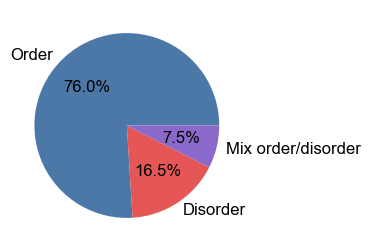

In [8]:
def func(pct):
    return f"{pct:.1f}%"

fig, ax = plt.subplots(figsize=(3,3))
ax.pie(plot_df, labels=["Order", "Disorder", "Mix order/disorder"], autopct=lambda pct: func(pct), colors=["#4C78A8","#E45756","#8b69ca"], textprops={'size':12})
#ax.legend(handles=legend_elements, loc=0, bbox_to_anchor=(0,1.0), frameon=False, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/disord_content_piechart.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/disord_content_piechart.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel f

In [ ]:
## Obtain list of PDB IDs per CATH superfamily, send to Soo-young to get first and last date of each superfamily
pdb_ids = []
cath_domains = []
# Downloaded from CATH server (v4.4)
with open("/Volumes/imb-luckgr/projects/interface_clustering/datasets/cluster_analysis/mapping/cath-domain-list.txt", 'r') as f:
    for line in f.readlines():
        if line[0] == "#":
            continue
        pdb_ids.append(line[0:4])
        cath_domain = ".".join([line[12],line[16:20].strip(" "),line[21:26].strip(" "), line[27:32].strip(" ")])
        cath_domains.append(cath_domain)

superfams = pd.DataFrame({'superfam':cath_domains, 'pdb_id':pdb_ids})
print(len(superfams))
superfams.drop_duplicates(inplace=True)

601328


In [20]:
pdb_dates = pd.read_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/cluster_analysis/whole_pdb_date_8digit.tsv", header=None, sep="\t")
pdb_dates.columns = ["pdb_id","date"]
pdb_dates["pdb_id"] = [x.lower() for x in pdb_dates.pdb_id]

superfams["date"] = superfams["pdb_id"].map(dict(zip(pdb_dates.pdb_id, pdb_dates.date)))

earliest_superfam_date = superfams.groupby("superfam")["date"].min().to_frame()
earliest_superfam_date.columns = ["date"]
earliest_superfam_date.reset_index(drop=True, inplace=True)
earliest_superfam_date.loc[:,"category"] = "Protein Folds (CATH)"
earliest_superfam_date["date"] = pd.to_datetime(earliest_superfam_date["date"], format="%Y%m%d")

earliest_superfam_date

,date,category
0,1991-08-12,Protein Folds (CATH)
1,2005-03-07,Protein Folds (CATH)
2,2005-06-17,Protein Folds (CATH)
3,2004-07-13,Protein Folds (CATH)
4,2008-07-15,Protein Folds (CATH)
...,...,...
6598,2009-01-09,Protein Folds (CATH)
6599,2011-09-12,Protein Folds (CATH)
6600,2004-11-15,Protein Folds (CATH)
6601,2014-05-14,Protein Folds (CATH)


In [21]:
# Downloaded from https://scop.berkeley.edu/downloads/update/dir.des.scope.2.08-2023-01-06.txt
with open("/Users/stromjoe/Downloads/dir.des.scope.2.08-2023-01-06.txt", "r") as f:
    content = f.readlines()

scop_ids = []
pdb_ids = []

for line in content[4:]:
    content_split = line.split("\t")
    if content_split[3] != "-":
        scop_ids.append(content_split[2])
        pdb_ids.append(content_split[4][0:4])

scope = pd.DataFrame({"scop_id":scop_ids, "pdb_id":pdb_ids})
scope["date"] = scope["pdb_id"].map(dict(zip(pdb_dates.pdb_id, pdb_dates.date)))

earliest_scope_date = scope.groupby("scop_id")["date"].min().to_frame()
earliest_scope_date.columns = ["date"]
earliest_scope_date.reset_index(drop=True, inplace=True)
earliest_scope_date.loc[:,"category"] = "Protein Folds (SCOPe)"
earliest_scope_date["date"] = pd.to_datetime(earliest_scope_date["date"], format="%Y%m%d")

earliest_scope_date

,date,category
0,2005-01-10,Protein Folds (SCOPe)
1,1999-12-13,Protein Folds (SCOPe)
2,1973-04-05,Protein Folds (SCOPe)
3,1990-10-11,Protein Folds (SCOPe)
4,2002-01-09,Protein Folds (SCOPe)
...,...,...
5428,2000-08-17,Protein Folds (SCOPe)
5429,1998-04-28,Protein Folds (SCOPe)
5430,1997-11-10,Protein Folds (SCOPe)
5431,1999-04-01,Protein Folds (SCOPe)


In [22]:
pdb_clusters["simple_pdb_id"] = [str(x)[0:4] for x in pdb_clusters["pdb_id"]]
pdb_clusters["date"] = pdb_clusters["simple_pdb_id"].map(dict(zip(pdb_dates.pdb_id, pdb_dates.date)))

earliest_int_date = pdb_clusters.groupby("intcluster")["date"].min().to_frame()
earliest_int_date.columns = ["date"]
earliest_int_date.reset_index(drop=True, inplace=True)
earliest_int_date.loc[:,"category"] = "Interface clusters"
earliest_int_date["date"] = pd.to_datetime(earliest_int_date["date"], format="%Y%m%d")

earliest_int_date = earliest_int_date[~earliest_int_date.index.isin(singleton_ids)]

earliest_int_date

,date,category
0,2013-02-27,Interface clusters
1,2012-03-27,Interface clusters
2,2024-03-27,Interface clusters
3,2024-03-27,Interface clusters
6,1999-02-01,Interface clusters
...,...,...
77161,2001-02-15,Interface clusters
77162,2020-12-11,Interface clusters
77163,2019-06-25,Interface clusters
77165,2022-09-30,Interface clusters


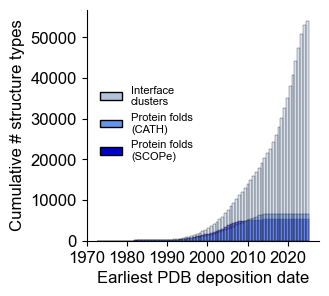

In [ ]:
earliest_dates = pd.concat([earliest_superfam_date, earliest_scope_date, earliest_int_date], axis=0)
earliest_dates.reset_index(inplace=True, drop=True)
earliest_dates

legend_elements = [mpl.patches.Patch(facecolor="lightsteelblue", edgecolor="black", label="Interface\nclusters"),
                   mpl.patches.Patch(facecolor="cornflowerblue", edgecolor="black", label="Protein folds\n(CATH)"),
                   mpl.patches.Patch(facecolor="mediumblue", edgecolor="black", label="Protein folds\n(SCOPe)")]
fig, ax = plt.subplots(figsize=(3,3))
sns.histplot(data=earliest_dates, x="date", hue="category", cumulative=True, ax=ax, palette=["cornflowerblue","mediumblue","lightsteelblue"])
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Earliest PDB deposition date", fontsize=12)
ax.set_ylabel("Cumulative # structure types", fontsize=12)
ax.legend(handles=legend_elements, loc=0, bbox_to_anchor=(0.5, 0.3), fontsize=8, frameon=False, title=None)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ifclusters_overtime.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ifclusters_overtime.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')